# 05 Insights and recommendations

This notebook converts the rent-inclusive candidate comparison
into one priority parish, two alternatives and a documented
due-diligence plan. It is a market-screening recommendation,
not approval to sign a lease.

## 1. Imports and validated shortlist

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import (
    FIGURES_DIR,
    FINAL_WEIGHTS,
    RANDOM_STATE,
    SENSITIVITY_ITERATIONS,
    TABLES_DIR,
)
from src.utils import save_figure, validate_required_columns

sns.set_theme(style="whitegrid", context="notebook")
shortlist_path = TABLES_DIR / "rent_inclusive_pilot_ranking.csv"
shortlist = pd.read_csv(shortlist_path)

required_columns = {
    "parish",
    "demand_proxy_score",
    "transit_access_score",
    "competition_opportunity_score",
    "rent_opportunity_score",
    "median_rent_eur_m2_month",
    "rent_sample_size",
    "pilot_opportunity_score",
    "pilot_rank",
}
validate_required_columns(shortlist, required_columns)
assert len(shortlist) == 10
assert shortlist["rent_sample_size"].ge(5).all()
shortlist.head()

,parish,demand_proxy_score,transit_access_score,competition_opportunity_score,median_rent_eur_m2_month,rent_sample_size,rent_opportunity_score,pilot_opportunity_score,pilot_rank
0,Areeiro,85.42,73.33,100.00,17.73,10,44.44,79.90,1
1,Lumiar,43.33,67.50,100.00,15.71,17,88.89,70.37,2
2,Arroios,94.17,95.00,10.81,17.50,15,61.11,68.58,3
3,Penha de França,60.42,27.08,100.00,13.91,15,100.00,67.92,4
4,Campolide,63.34,55.00,100.00,20.01,10,33.33,65.92,5


## 2. Four-component weight sensitivity

Five thousand plausible weight combinations are sampled around
the planned 35/25/25/15 weights. This checks whether the
recommendation depends on one exact subjective weighting.

In [2]:
component_columns = list(FINAL_WEIGHTS)
base_weights = np.array(
    [FINAL_WEIGHTS[column] for column in component_columns]
)
rng = np.random.default_rng(RANDOM_STATE)
sampled_weights = rng.dirichlet(
    base_weights * 40,
    size=SENSITIVITY_ITERATIONS,
)
score_matrix = (
    shortlist[component_columns].to_numpy() @ sampled_weights.T
)
order = np.argsort(-score_matrix, axis=0)
simulation_ranks = np.empty_like(order)
simulation_ranks[order, np.arange(SENSITIVITY_ITERATIONS)] = (
    np.arange(1, len(shortlist) + 1)[:, None]
)

sensitivity = pd.DataFrame(
    {
        "parish": shortlist["parish"],
        "top1_share": (simulation_ranks == 1).mean(axis=1) * 100,
        "top3_share": (simulation_ranks <= 3).mean(axis=1) * 100,
        "median_rank": np.median(simulation_ranks, axis=1),
        "best_rank": simulation_ranks.min(axis=1),
        "worst_rank": simulation_ranks.max(axis=1),
    }
)
sensitivity[["top1_share", "top3_share"]] = sensitivity[
    ["top1_share", "top3_share"]
].round(2)
decision_table = shortlist.merge(
    sensitivity,
    on="parish",
    how="left",
    validate="one_to_one",
).sort_values(["pilot_rank", "parish"])
decision_table.head()

,parish,demand_proxy_score,transit_access_score,competition_opportunity_score,median_rent_eur_m2_month,rent_sample_size,rent_opportunity_score,pilot_opportunity_score,pilot_rank,top1_share,top3_share,median_rank,best_rank,worst_rank
0,Areeiro,85.42,73.33,100.00,17.73,10,44.44,79.90,1,92.76,99.96,1.0,1,4
1,Lumiar,43.33,67.50,100.00,15.71,17,88.89,70.37,2,1.78,76.94,3.0,1,9
2,Arroios,94.17,95.00,10.81,17.50,15,61.11,68.58,3,4.32,52.68,3.0,1,8
3,Penha de França,60.42,27.08,100.00,13.91,15,100.00,67.92,4,1.14,45.88,4.0,1,10
4,Campolide,63.34,55.00,100.00,20.01,10,33.33,65.92,5,0.00,15.52,5.0,2,9


## 3. Priority parish and alternatives

In [3]:
final_shortlist = decision_table.head(3).copy()
final_shortlist["recommendation_role"] = [
    "priority",
    "alternative_1",
    "alternative_2",
]

assert final_shortlist.iloc[0]["parish"] == "Areeiro"
display(
    final_shortlist[
        [
            "recommendation_role",
            "parish",
            "pilot_opportunity_score",
            "median_rent_eur_m2_month",
            "rent_sample_size",
            "top1_share",
            "top3_share",
        ]
    ]
)

,recommendation_role,parish,pilot_opportunity_score,median_rent_eur_m2_month,rent_sample_size,top1_share,top3_share
0,priority,Areeiro,79.90,17.73,10,92.76,99.96
1,alternative_1,Lumiar,70.37,15.71,17,1.78,76.94
2,alternative_2,Arroios,68.58,17.50,15,4.32,52.68


**Priority: Areeiro.** It retains the highest balanced score,
combines strong demand and transit signals with no verified
active coworking location in the current inventory, and has
acceptable pilot asking rent.

**Alternative 1: Lumiar.** It offers lower pilot asking rent,
good transit accessibility and no verified active coworking
location, but its demand proxy is materially weaker than
Areeiro's.

**Alternative 2: Arroios.** It has the strongest combined
demand and accessibility signals and competitive asking rent.
Its main trade-off is seven verified coworking locations, so a
new site would need clear positioning and micro-location
differentiation.

## 4. Decision evidence and due-diligence actions

In [4]:
evidence = pd.DataFrame(
    [
        {
            "parish": "Areeiro",
            "role": "priority",
            "strength": (
                "Strong demand and transit, zero verified "
                "coworking supply, and mid-range pilot rent."
            ),
            "trade_off": (
                "Zero observed supply may reflect a discovery "
                "gap or weak site availability."
            ),
            "next_action": (
                "Inspect available 300-800 m² offices near "
                "Areeiro, Alameda and Roma-Areeiro stations."
            ),
        },
        {
            "parish": "Lumiar",
            "role": "alternative_1",
            "strength": (
                "Low pilot rent, good transit and zero verified "
                "coworking supply."
            ),
            "trade_off": (
                "Lower demand proxy and a more residential "
                "market profile."
            ),
            "next_action": (
                "Validate daytime worker/student catchments and "
                "test demand around metro nodes."
            ),
        },
        {
            "parish": "Arroios",
            "role": "alternative_2",
            "strength": (
                "Highest demand and accessibility signals with "
                "competitive pilot rent."
            ),
            "trade_off": (
                "Seven verified coworking competitors reduce "
                "white-space opportunity."
            ),
            "next_action": (
                "Map competitor capacity, pricing and customer "
                "segments before selecting a micro-location."
            ),
        },
    ]
)
evidence

,parish,role,strength,trade_off,next_action
0,Areeiro,priority,"Strong demand and transit, zero verified cowor...",Zero observed supply may reflect a discovery g...,Inspect available 300-800 m² offices near Aree...
1,Lumiar,alternative_1,"Low pilot rent, good transit and zero verified...",Lower demand proxy and a more residential mark...,Validate daytime worker/student catchments and...
2,Arroios,alternative_2,Highest demand and accessibility signals with ...,Seven verified coworking competitors reduce wh...,"Map competitor capacity, pricing and customer ..."


## 5. Decision-facing comparison

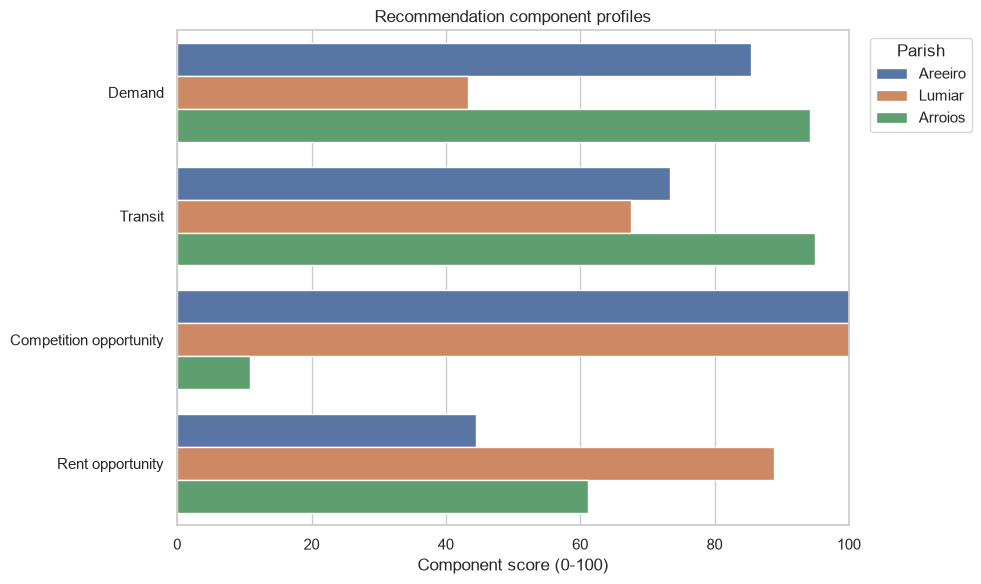

In [5]:
profile_columns = {
    "demand_proxy_score": "Demand",
    "transit_access_score": "Transit",
    "competition_opportunity_score": "Competition opportunity",
    "rent_opportunity_score": "Rent opportunity",
}
profile = final_shortlist[
    ["parish", *profile_columns]
].rename(columns=profile_columns).melt(
    id_vars="parish",
    var_name="component",
    value_name="score",
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=profile,
    x="score",
    y="component",
    hue="parish",
    ax=ax,
)
ax.set_title("Recommendation component profiles")
ax.set_xlabel("Component score (0-100)")
ax.set_ylabel("")
ax.set_xlim(0, 100)
ax.legend(title="Parish", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
figure_path = FIGURES_DIR / "09_recommendation_component_profiles.png"
save_figure(fig, figure_path)
plt.show()

## 6. Export recommendation tables

In [6]:
final_shortlist_path = TABLES_DIR / "final_shortlist.csv"
sensitivity_path = (
    TABLES_DIR / "rent_inclusive_shortlist_sensitivity.csv"
)
evidence_path = TABLES_DIR / "recommendation_evidence.csv"

final_shortlist.to_csv(final_shortlist_path, index=False)
sensitivity.to_csv(sensitivity_path, index=False)
evidence.to_csv(evidence_path, index=False)

print("Saved:", final_shortlist_path.relative_to(PROJECT_ROOT))
print("Saved:", sensitivity_path.relative_to(PROJECT_ROOT))
print("Saved:", evidence_path.relative_to(PROJECT_ROOT))

Saved: reports/tables/final_shortlist.csv
Saved: reports/tables/rent_inclusive_shortlist_sensitivity.csv
Saved: reports/tables/recommendation_evidence.csv


## 7. Recommendation boundary

Advance Areeiro to site-level due diligence, while retaining
Lumiar and Arroios as alternatives. Before any lease decision,
validate live availability, effective occupancy cost, usable
floorplate, footfall and catchment demand, competitor capacity,
planning constraints and unit economics. The parish score
prioritises where to investigate; it does not select a building
or forecast profitability.